# Ćwiczenie 4 — Porównanie węzłów równomiernych i Czebyszewa w interpolacji Newtona

## Zadanie

Rozważmy interpolację funkcji $f(x)=\frac{1}{x}$ na przedziale $[0.1, 1]$ przy użyciu węzłów równomiernych oraz węzłów Czebyszewa. Mamy zbadać, jak dobór węzłów wpływa na błąd interpolacji.

Dla $n=5, 10, 20$ węzłów:
1. Skonstruuj węzły równomierne i węzły Czebyszewa na przedziale $[a,b]$
2. Skonstruuj wielomian interpolacyjny metodą Newtona
3. Obliczyć błąd interpolacji na gęstej siatce punktów
4. Porównać wyniki wizualnie

Węzły Czebyszewa na przedziale $[a,b]$ wyznacza się ze wzoru:

$$x_k = \frac{a+b}{2} + \frac{b-a}{2} \cdot \cos\left(\frac{2k+1}{2n}\pi\right), \quad k=0,\dots,n-1$$

Błąd interpolateji wielomianem stopnia $n$ oszacowujemy jako:

$$E_n(x) = \frac{f^{(n+1)}(\xi)}{(n+1)!} \prod_{i=0}^{n}(x-x_i)$$

W praktyce obliczamy błąd punkt po punkcie jako $|f(x) - P_n(x)|$ na gęstej siatce.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def divided_diff_table(x, y):
    """Konstruuje tablicę ilorazów różnicowych."""
    n = len(x)
    TDD = np.zeros((n, n))
    TDD[:, 0] = y
    for j in range(1, n):
        for i in range(n - j):
            TDD[i, j] = (TDD[i+1, j-1] - TDD[i, j-1]) / (x[i+j] - x[i])
    return TDD

def newton_interpol(x_nodes, coeffs, x):
    """Ewaluacja wielomianu Newtona w punktach x.
    
    Parameters
    ----------
    x_nodes : array-like — węzły interpolacyjne
    coeffs  : array-like — współczyny $f[x_0], f[x_0,x_1], \\\\dots$
    x       : array-like — punkty ewaluacji
    """
    x = np.asarray(x, dtype=float)
    n = len(x_nodes)
    result = np.full_like(x, coeffs[0], dtype=float)
    prod = np.ones_like(x)
    for i in range(1, n):
        prod *= (x - x_nodes[i-1])
        result += coeffs[i] * prod
    return result

def chebyshev_nodes(n, a, b):
    """Węzły Czebyszewa na przedziale $[a,b]$."""
    k = np.arange(n)
    return 0.5 * (a + b) + 0.5 * (b - a) * np.cos((2 * k + 1) * np.pi / (2 * n))

def uniform_nodes(n, a, b):
    """Węzły równomierne na przedziale $[a,b]$."""
    return np.linspace(a, b, n)

In [3]:
f = lambda x: 1.0 / x

a, b = 0.1, 1.0
fine_x = np.linspace(a, b, 1001)
fine_y = f(fine_x)

n_values = [5, 10, 20]

In [4]:
results = {}
for n in n_values:
    # Węzły równomierne
    un = uniform_nodes(n, a, b)
    uy = f(un)
    utdd = divided_diff_table(un, uy)
    ucoeffs = utdd[0, :]
    u_interp = newton_interpol(un, ucoeffs, fine_x)
    u_err = np.abs(fine_y - u_interp)

    # Węzły Czebyszewa
    cn = chebyshev_nodes(n, a, b)
    cn.sort()
    cy = f(cn)
    ctdd = divided_diff_table(cn, cy)
    ccoeffs = ctdd[0, :]
    c_interp = newton_interpol(cn, ccoeffs, fine_x)
    c_err = np.abs(fine_y - c_interp)

    results[n] = {
        "uniform_nodes": un, "uniform_interp": u_interp, "uniform_err": u_err,
        "chebyshev_nodes": cn, "chebyshev_interp": c_interp, "chebyshev_err": c_err
    }

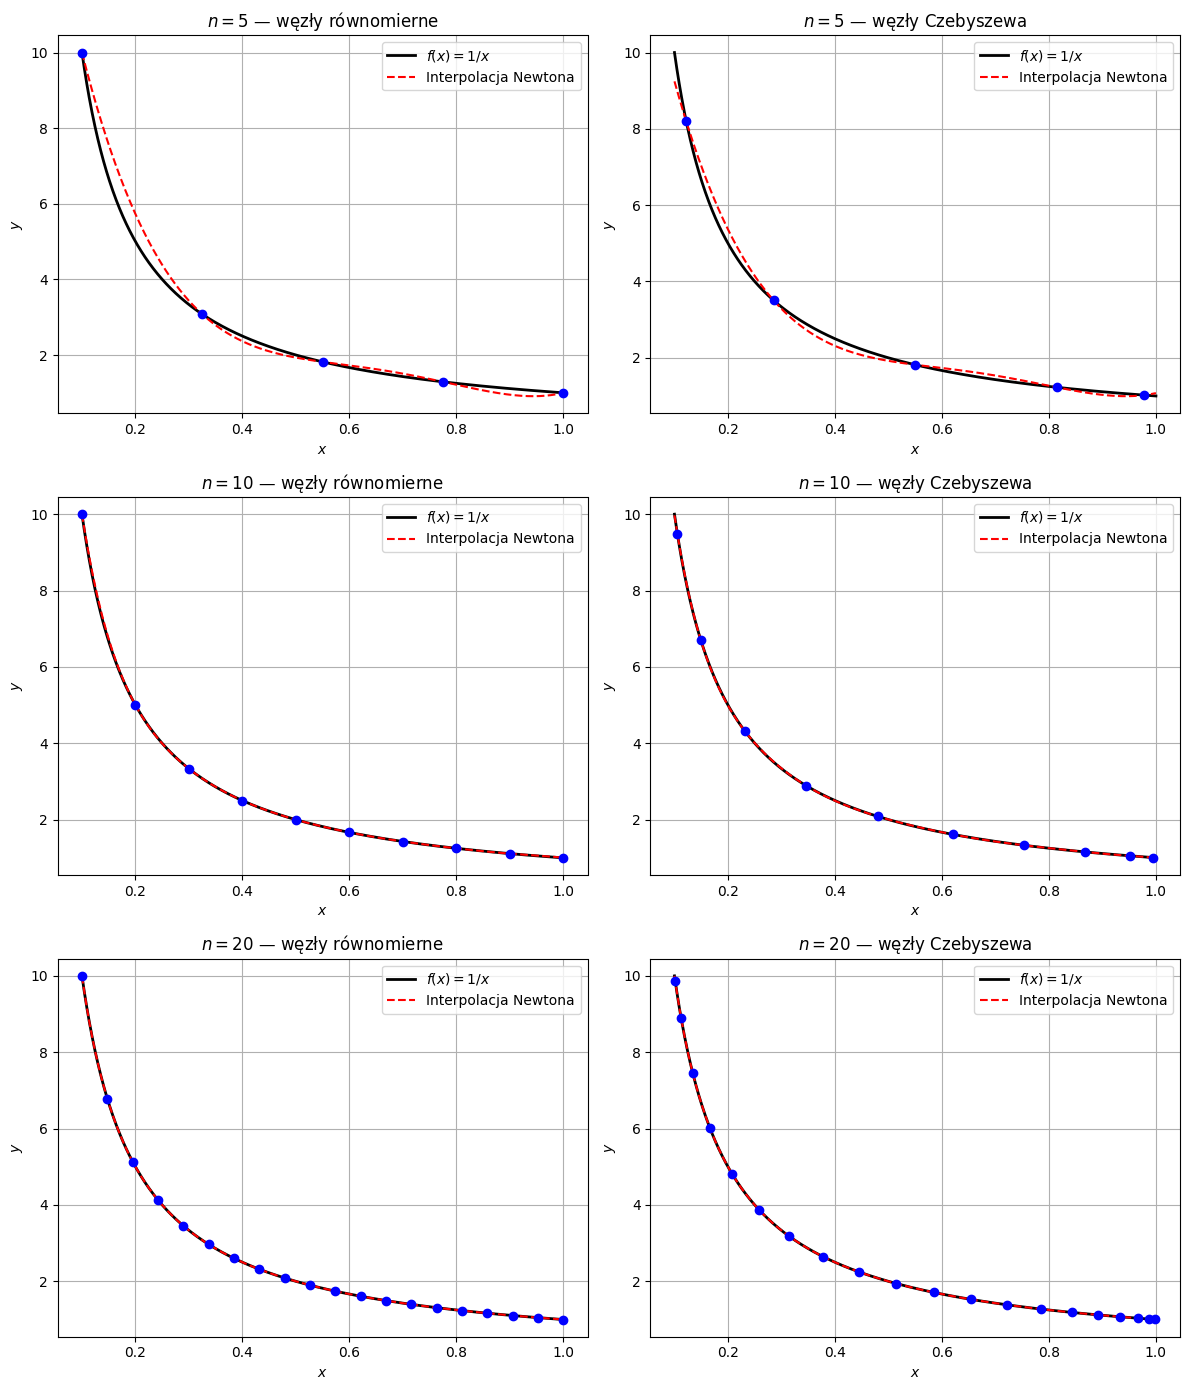

In [5]:
fig, axes = plt.subplots(len(n_values), 2, figsize=(12, 14))

for idx, n in enumerate(n_values):
    res = results[n]

    # Lewa kolumna — węzły równomierne
    axL = axes[idx, 0]
    axL.plot(fine_x, fine_y, "k", linewidth=2, label="$f(x)=1/x$")
    axL.plot(fine_x, res["uniform_interp"], "r--", linewidth=1.5,
             label="Interpolacja Newtona")
    axL.plot(res["uniform_nodes"], f(res["uniform_nodes"]), "bo",
             markersize=6)
    axL.set_title(f"$n={n}$ — węzły równomierne")
    axL.set_xlabel("$x$")
    axL.set_ylabel("$y$")
    axL.legend(loc="best")
    axL.grid(True)

    # Prawa kolumna — węzły Czebyszewa
    axR = axes[idx, 1]
    axR.plot(fine_x, fine_y, "k", linewidth=2, label="$f(x)=1/x$")
    axR.plot(fine_x, res["chebyshev_interp"], "r--", linewidth=1.5,
             label="Interpolacja Newtona")
    axR.plot(res["chebyshev_nodes"], f(res["chebyshev_nodes"]), "bo",
             markersize=6)
    axR.set_title(f"$n={n}$ — węzły Czebyszewa")
    axR.set_xlabel("$x$")
    axR.set_ylabel("$y$")
    axR.legend(loc="best")
    axR.grid(True)

plt.tight_layout()
plt.show()

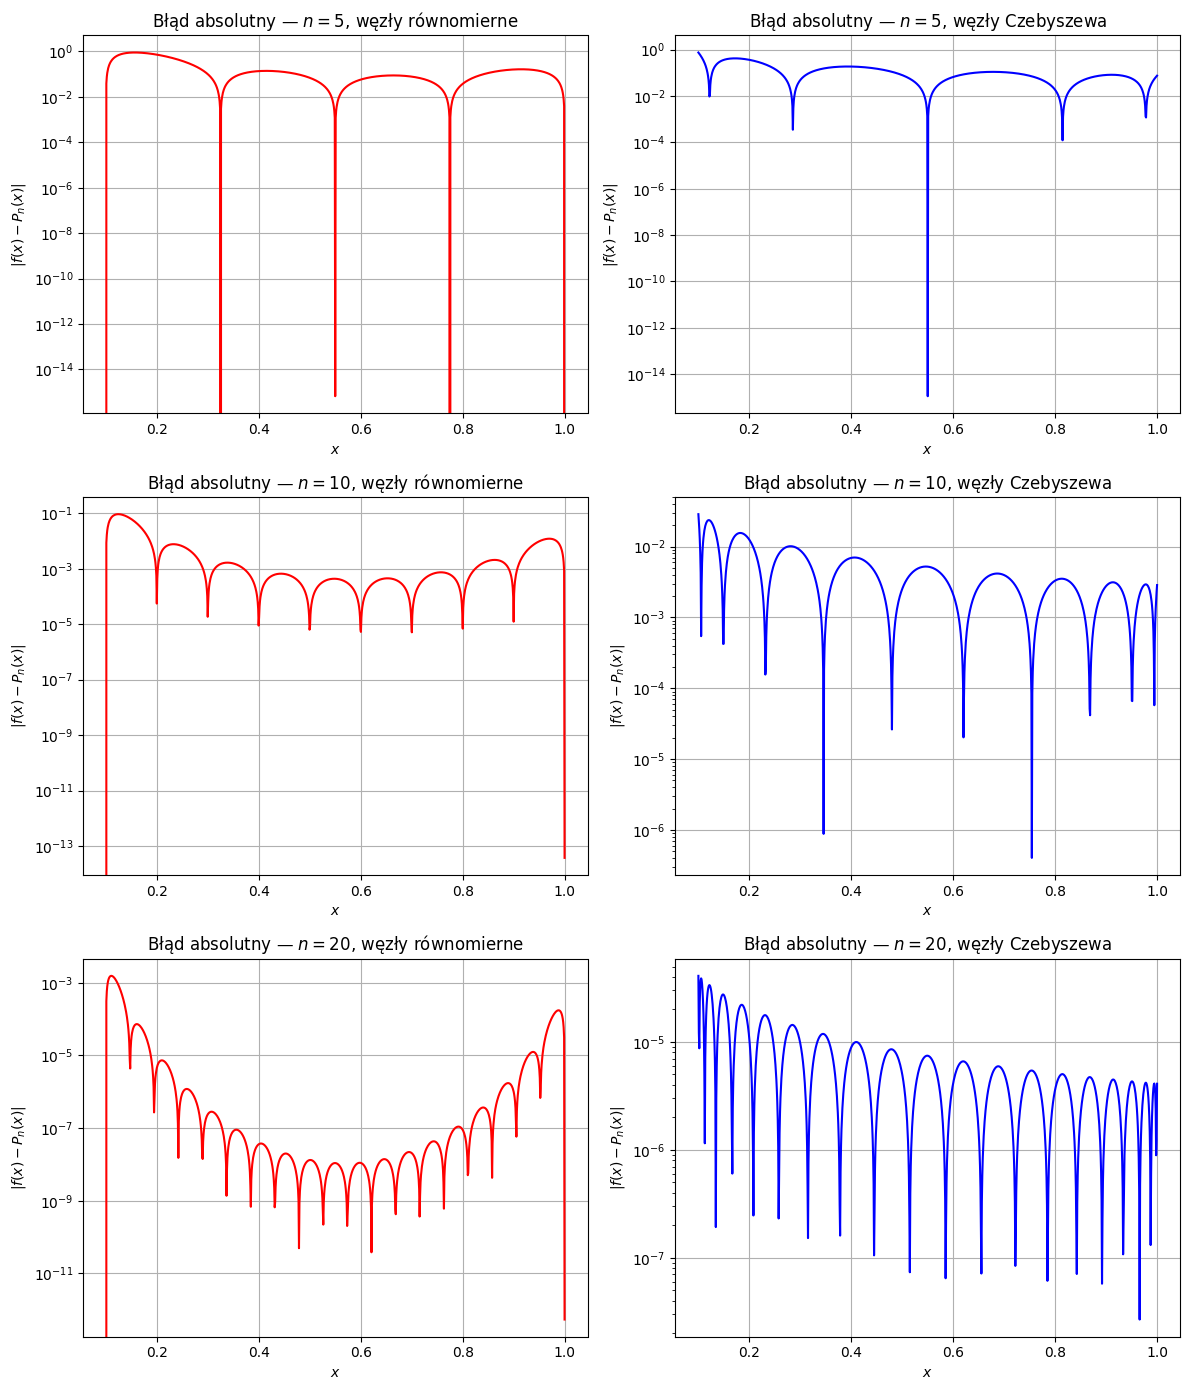

In [6]:
fig, axes = plt.subplots(len(n_values), 2, figsize=(12, 14))

for idx, n in enumerate(n_values):
    res = results[n]

    axL = axes[idx, 0]
    axL.semilogy(fine_x, res["uniform_err"], "r-", linewidth=1.5)
    axL.set_title(f"Błąd absolutny — $n={n}$, węzły równomierne")
    axL.set_xlabel("$x$")
    axL.set_ylabel("$|f(x)-P_n(x)|$")
    axL.grid(True)

    axR = axes[idx, 1]
    axR.semilogy(fine_x, res["chebyshev_err"], "b-", linewidth=1.5)
    axR.set_title(f"Błąd absolutny — $n={n}$, węzły Czebyszewa")
    axR.set_xlabel("$x$")
    axR.set_ylabel("$|f(x)-P_n(x)|$")
    axR.grid(True)

plt.tight_layout()
plt.show()

In [7]:
max_err_uniform = []
max_err_cheb = []

for n in n_values:
    res = results[n]
    max_err_uniform.append(np.max(res["uniform_err"]))
    max_err_cheb.append(np.max(res["chebyshev_err"]))

print(f"{'n':>4} | {'max_err (równomierne)':>22} | {'max_err (Czebyszewa)':>18}")
print("-" * 52)
for i, n in enumerate(n_values):
    print(f"{n:4d} | {max_err_uniform[i]:22.6e} | {max_err_cheb[i]:18.6e}")

   n |  max_err (równomierne) | max_err (Czebyszewa)
----------------------------------------------------
   5 |           9.014792e-01 |       7.556328e-01
  10 |           9.329324e-02 |       2.863078e-02
  20 |           1.557149e-03 |       4.098626e-05


## Podsumowanie

Jak widać z wyników, węzły Czebyszewa rozkładają błąd interpolacji znacznie bardziej równomiernie niż węzły równomierne. Dla węzłów równomiernych błąd rośnie eksponencjalnie na krańcach przedziału (zjawisko Runge'a), podczas gdy węzły Czebyszewa minimalizują maksymalny błąd poprzez gęstszy rozkład punktów na krawędziach.

**Ćwiczenie:** Sprawdź, jak zachowuje się interpolacja dla $n=30$ węzłów. Czy różnica między obiema metodami staje się jeszcze bardziej widoczna?